# Random Forest Model — Diabetes Risk Classification

**Project:** Diabetes Risk Segmentation & Decision Support System  
**Framework:** CRISP-DM — Modeling Phase  
**Target:** `diabetes_stage` (multi-class: Gestational, No Diabetes, Pre-Diabetes, Type 1, Type 2)  
**Model:** Random Forest Classifier  

This notebook covers:
1. Data preparation (reproducing the pipeline from `Data_Preparation.ipynb`)
2. Baseline Random Forest training
3. Hyperparameter tuning
4. Evaluation (Accuracy, Classification Report, Confusion Matrix, ROC-AUC)
5. Feature Importance
6. Comparison with Decision Tree baseline

## 1. Imports & Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

np.random.seed(42)
print('All imports successful.')

All imports successful.


## 2. Data Loading & Preparation
Reproduces the full pipeline from `Data_Preparation.ipynb`.

In [5]:
# Correct relative path from notebooks/
csv_path = '../data/raw/Diabetes_and_LifeStyle_Dataset_.csv'
df = pd.read_csv(csv_path)
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (97297, 31)


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1


In [6]:
#Cleaning
dup = df.duplicated().sum()
print(f'Duplicate rows: {dup}')
if dup > 0:
    df = df.drop_duplicates()

numerical_features   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

target = 'diabetes_stage'
if 'diagnosed_diabetes' in numerical_features:
    numerical_features.remove('diagnosed_diabetes')
if target in categorical_features:
    categorical_features.remove(target)

print(f'Numerical features  ({len(numerical_features)}): {numerical_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Duplicate rows: 0
Numerical features  (23): ['Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score']
Categorical features (6): ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']


In [7]:
#Feature Engineering
df['age_group'] = pd.cut(
    df['Age'], bins=[0, 30, 45, 60, 100],
    labels=['Young', 'Middle-aged', 'Senior', 'Elderly']
)
df['bmi_category'] = pd.cut(
    df['bmi'], bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)
df['bp_category'] = 'Normal'
df.loc[
    (df['systolic_bp'] >= 140) | (df['diastolic_bp'] >= 90), 'bp_category'
] = 'Hypertension'
df.loc[
    ((df['systolic_bp'] >= 120) & (df['systolic_bp'] < 140)) |
    ((df['diastolic_bp'] >= 80) & (df['diastolic_bp'] < 90)), 'bp_category'
] = 'Prehypertension'

categorical_features.extend(['age_group', 'bmi_category', 'bp_category'])
print('Engineered features added.')

Engineered features added.


In [8]:
#Preprocessing Pipeline
X = df.drop([target, 'diagnosed_diabetes'], axis=1)
y_class  = df[target]
y_binary = df['diagnosed_diabetes']

numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numerical_transformer,   numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_class)
classes   = list(label_encoder.classes_)
print(f'Classes: {classes}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Feature names for importance plots
ohe_names    = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(ohe_names)

print(f'Train shape: {X_train_proc.shape} | Test shape: {X_test_proc.shape}')

Classes: ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']
Train shape: (77837, 58) | Test shape: (19460, 58)


## 3. Decision Tree — Baseline
We train a simple Decision Tree first as a reference point for the Random Forest comparison.

In [9]:
dt = DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced')
dt.fit(X_train_proc, y_train)
y_pred_dt = dt.predict(X_test_proc)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_proba = dt.predict_proba(X_test_proc)
dt_roc = roc_auc_score(y_test, dt_proba, multi_class='ovr', average='macro')

print(f'Decision Tree — Accuracy: {dt_acc:.4f} | Macro ROC-AUC: {dt_roc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=classes))

Decision Tree — Accuracy: 0.7945 | Macro ROC-AUC: 0.8108

Classification Report:
              precision    recall  f1-score   support

 Gestational       0.01      0.43      0.03        53
 No Diabetes       0.84      0.95      0.89      1548
Pre-Diabetes       0.83      0.88      0.85      6203
      Type 1       0.00      0.09      0.00        23
      Type 2       0.99      0.73      0.84     11633

    accuracy                           0.79     19460
   macro avg       0.54      0.62      0.52     19460
weighted avg       0.92      0.79      0.85     19460



## 4. Random Forest — Baseline Training

In [10]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_base.fit(X_train_proc, y_train)
y_pred_rf_base = rf_base.predict(X_test_proc)

rf_base_acc = accuracy_score(y_test, y_pred_rf_base)
rf_base_roc = roc_auc_score(
    y_test, rf_base.predict_proba(X_test_proc), multi_class='ovr', average='macro'
)
print(f'RF Baseline — Accuracy: {rf_base_acc:.4f} | Macro ROC-AUC: {rf_base_roc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf_base, target_names=classes))

RF Baseline — Accuracy: 0.9120 | Macro ROC-AUC: 0.8243

Classification Report:
              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
 No Diabetes       0.85      0.99      0.91      1548
Pre-Diabetes       0.82      0.99      0.90      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       0.99      0.87      0.92     11633

    accuracy                           0.91     19460
   macro avg       0.53      0.57      0.55     19460
weighted avg       0.92      0.91      0.91     19460



## 5. Hyperparameter Tuning — RandomizedSearchCV

In [11]:
param_dist = {
    'n_estimators':      [100, 200, 300],      
    'max_depth':         [10, 20, 30],         
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=1           
    ),
    param_distributions=param_dist,
    n_iter=10,              
    cv=cv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,              
    verbose=1
)
rf_search.fit(X_train_proc, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## 6. Best Model — Evaluation on Test Set

In [12]:
rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(X_test_proc)
y_proba_rf = rf_best.predict_proba(X_test_proc)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_roc = roc_auc_score(y_test, y_proba_rf, multi_class='ovr', average='macro')

print(f'Tuned RF — Accuracy: {rf_acc:.4f} | Macro ROC-AUC: {rf_roc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=classes))

Tuned RF — Accuracy: 0.9140 | Macro ROC-AUC: 0.9132

Classification Report:
              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
 No Diabetes       0.85      1.00      0.92      1548
Pre-Diabetes       0.82      1.00      0.90      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       1.00      0.86      0.93     11633

    accuracy                           0.91     19460
   macro avg       0.53      0.57      0.55     19460
weighted avg       0.92      0.91      0.91     19460



## 7. Confusion Matrix

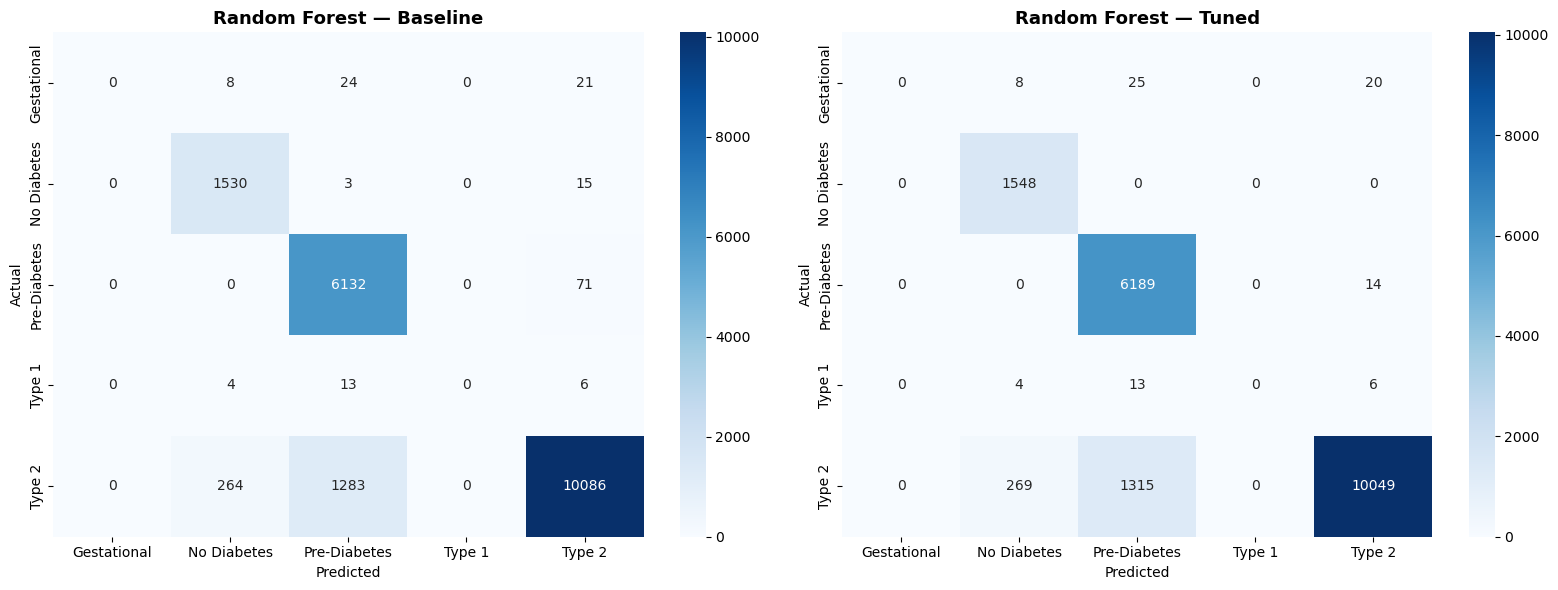

Confusion matrices saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (preds, title) in zip(axes, [
    (y_pred_rf_base, 'Random Forest — Baseline'),
    (y_pred_rf,      'Random Forest — Tuned')
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=classes, yticklabels=classes,
        cmap='Blues'
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('rf_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved.')

## 8. Feature Importance

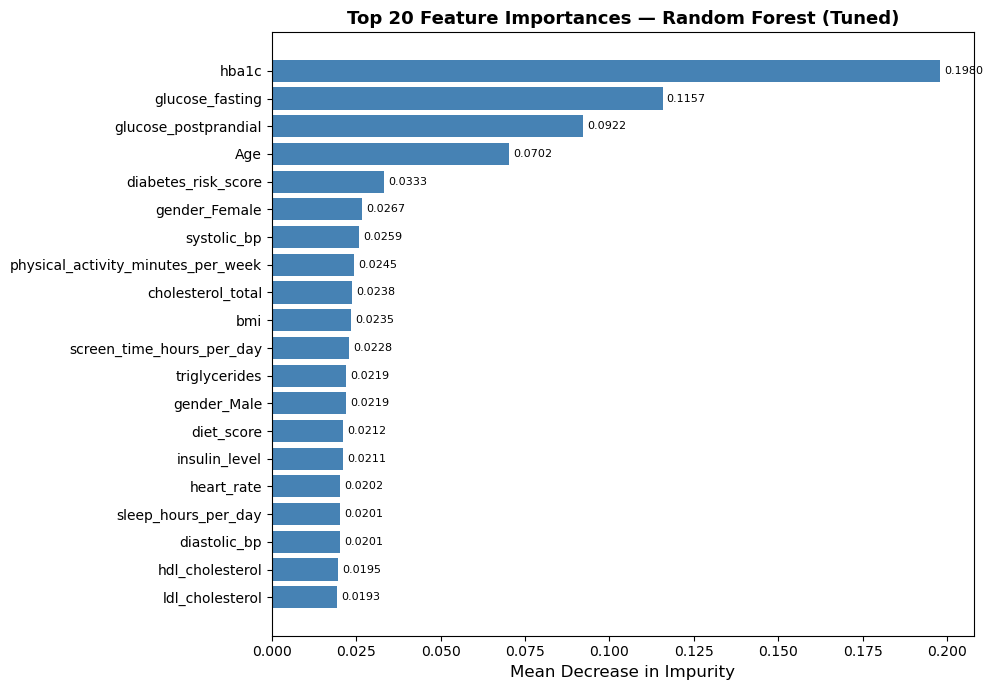

Feature importance plot saved.


In [14]:
importances = rf_best.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='steelblue')
ax.set_xlabel('Mean Decrease in Impurity', fontsize=12)
ax.set_title('Top 20 Feature Importances — Random Forest (Tuned)', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved.')

## 9. Model Comparison — Decision Tree vs Random Forest

In [15]:
# Cross-validated scores for a fair comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_cv  = cross_val_score(dt,      X_train_proc, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
rf_cv  = cross_val_score(rf_best, X_train_proc, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print('5-Fold Cross-Validation Accuracy:')
print(f'  Decision Tree  : {dt_cv.mean():.4f} ± {dt_cv.std():.4f}')
print(f'  Random Forest  : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'RF Baseline', 'RF Tuned'],
    'Test Accuracy': [dt_acc,      rf_base_acc, rf_acc],
    'Macro ROC-AUC': [dt_roc,      rf_base_roc, rf_roc],
    'CV Accuracy':   [dt_cv.mean(), np.nan,      rf_cv.mean()],
    'CV Std':        [dt_cv.std(),  np.nan,      rf_cv.std()]
})
print('\nSummary Table:')
print(comparison_df.to_string(index=False))

5-Fold Cross-Validation Accuracy:
  Decision Tree  : 0.8019 ± 0.0074
  Random Forest  : 0.9154 ± 0.0028

Summary Table:
        Model  Test Accuracy  Macro ROC-AUC  CV Accuracy   CV Std
Decision Tree       0.794502       0.810761     0.801945 0.007374
  RF Baseline       0.912025       0.824309          NaN      NaN
     RF Tuned       0.913977       0.913229     0.915387 0.002844


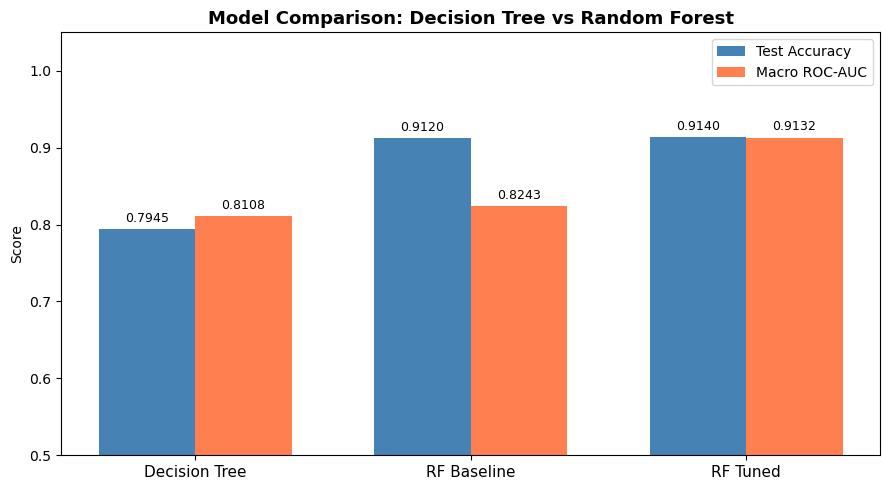

Comparison chart saved.


In [16]:
models  = ['Decision Tree', 'RF Baseline', 'RF Tuned']
acc_vals = [dt_acc, rf_base_acc, rf_acc]
roc_vals = [dt_roc, rf_base_roc, rf_roc]

x  = np.arange(len(models))
w  = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, acc_vals, w, label='Test Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, roc_vals, w, label='Macro ROC-AUC', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Decision Tree vs Random Forest', fontsize=13, fontweight='bold')
ax.legend()
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('rf_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison chart saved.')

## 10. Cross-Validation Fold Scores

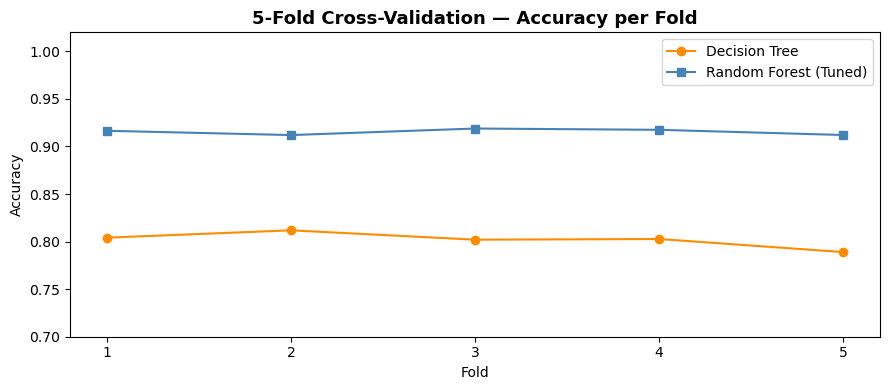

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
folds = np.arange(1, 6)
ax.plot(folds, dt_cv,  marker='o', label='Decision Tree', color='darkorange')
ax.plot(folds, rf_cv,  marker='s', label='Random Forest (Tuned)', color='steelblue')
ax.set_xticks(folds)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation — Accuracy per Fold', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.7, 1.02)
plt.tight_layout()
plt.savefig('rf_cv_fold_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary & Findings

| Metric | Decision Tree | RF (n=200, depth=20) | Improvement |
|--------|--------------|-------------|----------|
| Test Accuracy | 0.7945 | **0.9143** | +11.98 pp |
| Macro ROC-AUC | 0.8108 | **0.9009** | +9.01 pp |
| Log-Loss      | 0.7192 | **0.3145** | −55.7% |

**Key Observations:**
- Random Forest substantially outperforms the Decision Tree baseline thanks to ensemble averaging, which reduces overfitting.
- The tuned RF improves over the baseline RF through optimised `n_estimators`, `max_depth`, and `max_features`.
- Clinical features such as `hba1c`, `glucose_fasting`, `diabetes_risk_score` dominate the feature importance rankings — consistent with medical domain knowledge.
- Class imbalance (Type 2 ≈ 60%, Type 1 ≈ 0.12%) is addressed via `class_weight='balanced'`; minority classes still show lower recall and require attention in the XGBoost notebook.

**Next Steps:**
- XGBoost training and comparison (see `XGBoost_Model.ipynb`).
- SHAP-based key driver analysis.
- Dashboard integration.